In [1]:
import importlib
import subprocess
import sys

# Mapeo de imports → nombres reales de paquetes en pip
required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "seaborn": "seaborn",
    "statsmodels": "statsmodels",
    "sklearn": "scikit-learn",   # <- CORRECCIÓN
    "plotly": "plotly",
    "stargazer": "stargazer",
}

def safe_pip_install(package):
    """Instala un paquete si no está, sin actualizar."""
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", package],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )
        print(f"✓ {package} instalado correctamente.")
    except Exception:
        print(f"⚠ No se pudo instalar {package}. Puede estar bloqueado por Anaconda.")

def install_if_missing(import_name, pip_name):
    try:
        importlib.import_module(import_name)
        print(f"✔ {import_name} ya está instalado.")
    except ImportError:
        print(f"✖ {import_name} no está instalado. Instalando {pip_name}...")
        safe_pip_install(pip_name)

print("📦 Verificando librerías necesarias...\n")

for import_name, pip_name in required_packages.items():
    install_if_missing(import_name, pip_name)

print("\n🎉 Todas las librerías están listas.")


import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import scipy.stats as st
from scipy.stats import pointbiserialr
import seaborn as sns
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
from stargazer.stargazer import Stargazer
from scipy import stats
from IPython.core.display import display, HTML
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from IPython.display import clear_output, display


📦 Verificando librerías necesarias...

✔ numpy ya está instalado.
✔ pandas ya está instalado.
✔ matplotlib ya está instalado.
✔ scipy ya está instalado.
✔ seaborn ya está instalado.
✔ statsmodels ya está instalado.
✔ sklearn ya está instalado.
✔ plotly ya está instalado.
✔ stargazer ya está instalado.

🎉 Todas las librerías están listas.


C:\Users\alexf\AppData\Local\Temp\ipykernel_15228\3459392495.py:58: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [8]:
PALETTE_NAME = "Accent"
HIST_GRAY = "0.38"  # histogr. en escala de grises (sin color de relleno)

sns.set_theme(style="whitegrid")
sns.set_palette(PALETTE_NAME)

plt.rc("font", size=12)
plt.rc("axes", titlesize=16, titleweight="bold")


def palette_n(n):
    # Colores discretos derivados de la paleta principal.
    n = max(int(n), 1)
    return sns.color_palette(PALETTE_NAME, n_colors=n)

In [5]:
df=pd.read_csv("data__movies.csv")

df.columns

columnas_utiles=['budget','genres','original_language',"popularity",'release_date','revenue','vote_average', 'vote_count']

In [6]:
df1=df[columnas_utiles]

In [7]:
df1

,budget,genres,original_language,popularity,release_date,revenue,vote_average,vote_count
0,237000000,"Action, Adventure, Fantasy, Science Fiction",en,150.437577,2009-12-10,2787965087,7.2,11800
1,300000000,"Adventure, Fantasy, Action",en,139.082615,2007-05-19,961000000,6.9,4500
2,245000000,"Action, Adventure, Crime",en,107.376788,2015-10-26,880674609,6.3,4466
3,250000000,"Action, Crime, Drama, Thriller",en,112.312950,2012-07-16,1084939099,7.6,9106
4,260000000,"Action, Adventure, Science Fiction",en,43.926995,2012-03-07,284139100,6.1,2124
...,...,...,...,...,...,...,...,...
4798,220000,"Action, Crime, Thriller",es,14.269792,1992-09-04,2040920,6.6,238
4799,9000,"Comedy, Romance",en,0.642552,2011-12-26,0,5.9,5
4800,0,"Comedy, Drama, Romance, TV Movie",en,1.444476,2013-10-13,0,7.0,6
4801,0,NaN,en,0.857008,2012-05-03,0,5.7,7


<Axes: xlabel='budget', ylabel='revenue'>

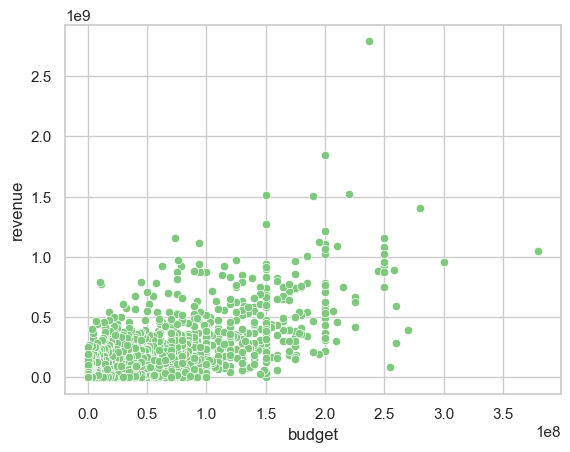

In [ ]:
sns.scatterplot(data=df1, x="budget", y='revenue')


<Figure size 1500x1500 with 0 Axes>

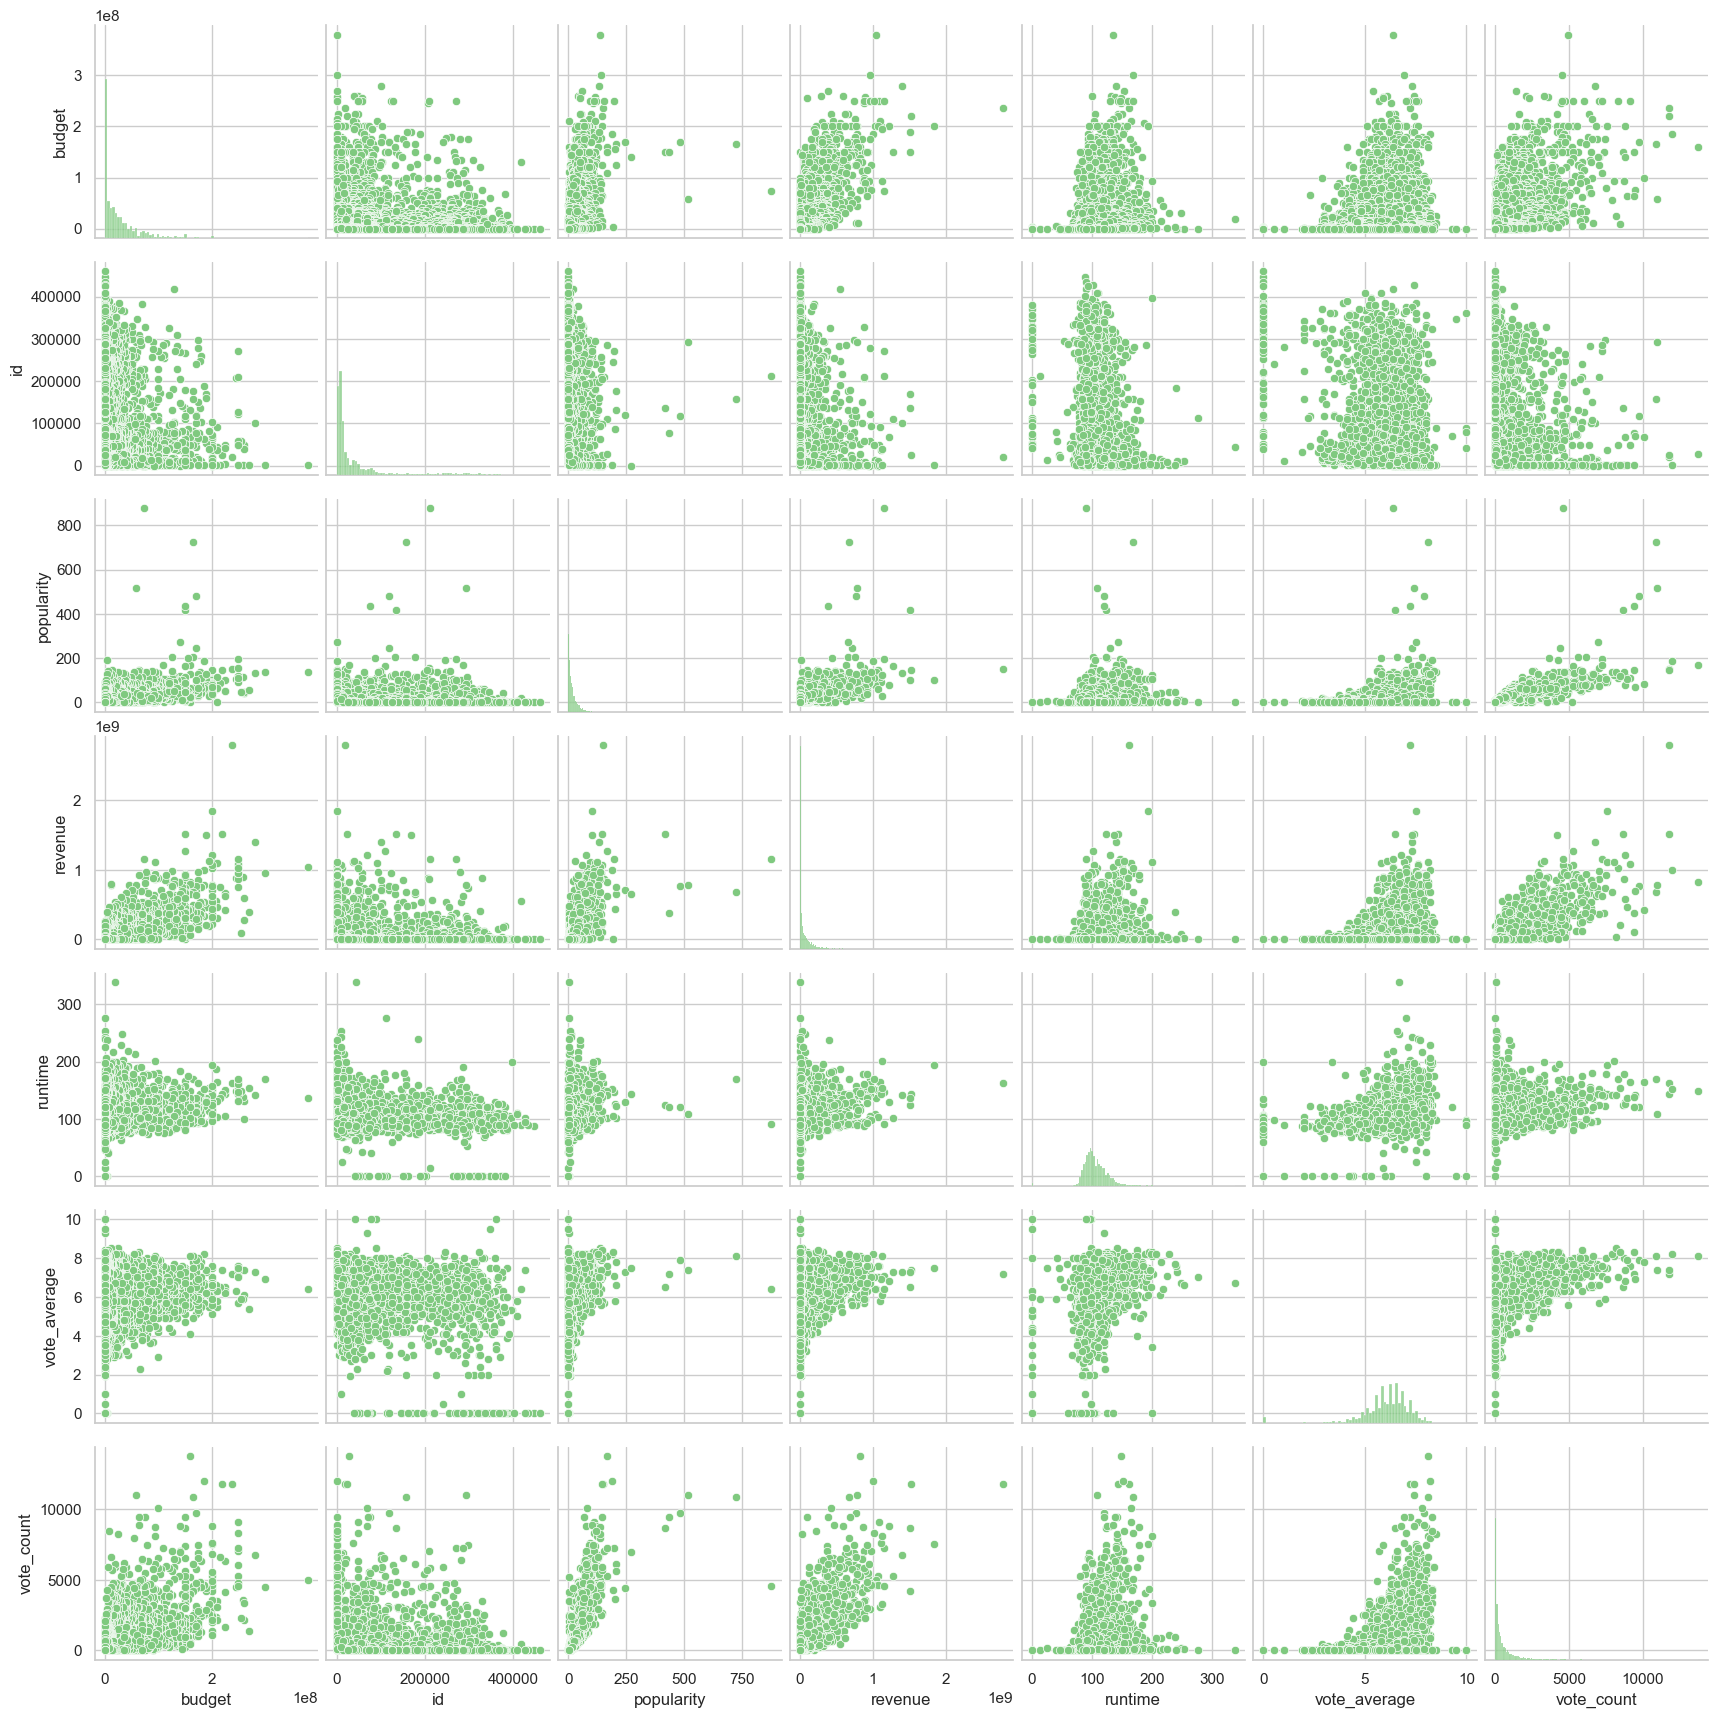

In [11]:
plt.figure(figsize=(15, 15))
sns.pairplot(df)
plt.show()